In [182]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [183]:
def f(x, y):
    return 10 - (x - 2) * np.exp(-(x - 2)) - (y - 3) * np.exp(-(y - 3))

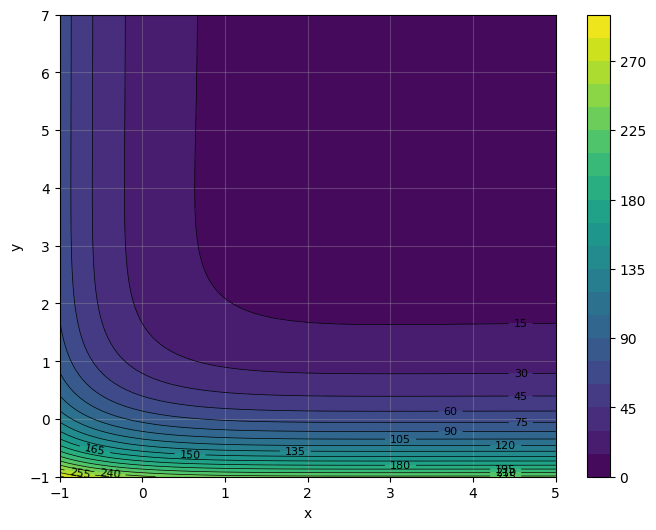

In [184]:
x = np.linspace(-1, 5, 100)
y = np.linspace(-1, 7, 100)
X, Y = np.meshgrid(x, y)
Z = f(X, Y)

plt.figure(figsize=(8, 6))
cp = plt.contourf(X, Y, Z, levels=20, cmap='viridis')
plt.colorbar(cp)
line_colors = plt.contour(X, Y, Z, levels=20, colors='black', linewidths=0.5)
plt.clabel(line_colors, inline=True, fontsize=8)

plt.xlabel('x')
plt.ylabel('y')
plt.grid(alpha=0.3)
plt.show()

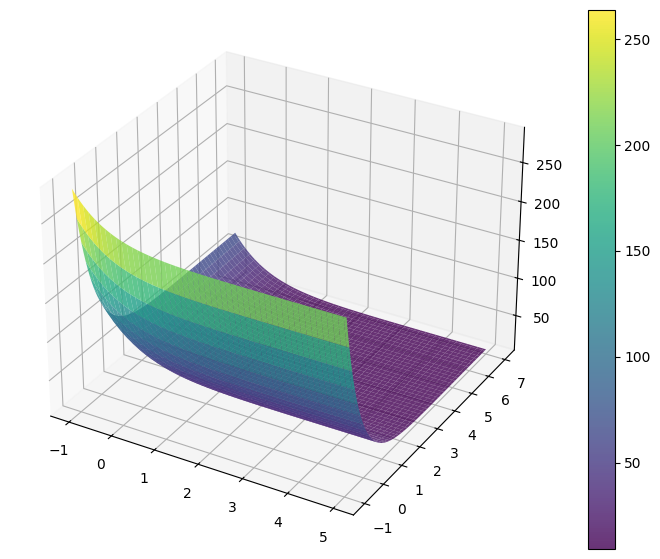

In [185]:
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='viridis', edgecolor='none', alpha=0.8)
fig.colorbar(surf)
plt.show()

Алгоритм Золотого сечения из прошлой ЛР

In [186]:
def golden_section(f, a, b, eps):
    iterations = 0
    phi = 0.382
    x1 = a + phi * (b - a)
    x2 = b -  phi * (b - a)
    f1, f2 = f(x1), f(x2)
    
    while b - a > eps:
        iterations += 1
        if f1 > f2:
            a, x1, f1 = x1, x2, f2
            x2 = b - phi * (b - a)
            f2 = f(x2)
        else:
            b, x2, f2 = x2, x1, f1
            x1 = a + phi * (b - a)
            f1 = f(x1)
    
    return (a + b) / 2

In [187]:
def gauss_seidel(f, x0, eps=1e-6, max_iter=1000):
    x = np.array(x0, dtype=float)
    y = np.zeros(2)
    y[:] = x[:]
    k = 1
    j = 1
    history = [x.copy()]
    
    while k <= max_iter:
        x_prev = x.copy()
        
        while j <= 2:
            if j == 1:
                def f_lambda1(lambd):
                    return f(y[0] + lambd, y[1])
                
                lambda_opt = golden_section(f_lambda1, -5, 5, eps/10)
                y[0] = y[0] + lambda_opt
            else:
                def f_lambda2(lambd):
                    return f(y[0], y[1] + lambd)
                
                lambda_opt = golden_section(f_lambda2, -5, 5, eps/10)
                y[1] = y[1] + lambda_opt
            
            j += 1
            history.append(y.copy())
        
        x[:] = y[:]
        
        if np.linalg.norm(x - x_prev) < eps:
            break
        
        y[:] = x[:]
        j = 1
        k += 1
    
    return x, history

In [188]:
def get_gradient(f, x, y, h=1e-8):
    grad_x = (f(x + h, y) - f(x - h, y)) / (2 * h)
    grad_y = (f(x, y + h) - f(x, y - h)) / (2 * h)
    return grad_x, grad_y

In [189]:
def steepest_descent(f, x0, eps=1e-6, max_iter=1000):
    x, y = float(x0[0]), float(x0[1])
    k = 1
    history = [(x, y)]
    
    while k <= max_iter:
        gx, gy = get_gradient(f, x, y)
        grad_norm = np.sqrt(gx**2 + gy**2)
        
        if grad_norm < eps:
            break
        
        sx = -gx / grad_norm
        sy = -gy / grad_norm
        
        def f_lambda(lmbd):
            return f(x + lmbd * sx, y + lmbd * sy)
        
        l_opt = golden_section(f_lambda, 0, 10, eps/10)
        
        x = x + l_opt * sx
        y = y + l_opt * sy
        
        history.append((x, y))
        
        k += 1

    return (x, y), history

In [190]:
def hooke_jeeves(f, x0, h=0.5, alpha=2.0, eps=1e-6, max_iter=1000):
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    k = 0
    
    def exploratory_search(base_x, step):
        new_x = base_x.copy()
        for i in range(len(new_x)):
            f_old = f(*new_x)
            
            new_x[i] += step
            if f(*new_x) >= f_old:
                new_x[i] -= 2 * step
                
                if f(*new_x) >= f_old:
                    new_x[i] += step
        return new_x

    while k < max_iter and h > eps:
        x_new = exploratory_search(x, h)
        
        if f(*x_new) < f(*x):
            while True:
                x_prev = x.copy()
                x = x_new.copy()
                history.append(x.copy())
                
                pattern_point = x + (x - x_prev)
                x_after_pattern = exploratory_search(pattern_point, h)
                
                if f(*x_after_pattern) < f(*x):
                    x_new = x_after_pattern
                else:
                    break
        else:
            h /= alpha
            
        k += 1
        
    return x, history

In [191]:
def rosenbrock(f, x0, eps=1e-6, max_iter=1000, alpha = 1, beta = -0.1):
    n = len(x0)
    x = np.array(x0, dtype=float)
    d = np.eye(n)
    step = np.ones(n) * 0.1
    alpha = alpha
    beta = beta
    
    history = [x.copy()]
    k = 0
    
    while k < max_iter:
        x_start_cycle = x.copy()
        success = np.zeros(n, dtype=bool)
        failure = np.zeros(n, dtype=bool)
        
        while not (all(success) and all(failure)):
            for i in range(n):
                x_next = x + step[i] * d[i]
                if f(*x_next) <= f(*x):
                    x = x_next
                    step[i] *= alpha
                    success[i] = True
                else:
                    step[i] *= beta
                    failure[i] = True
            history.append(x.copy())

        if np.linalg.norm(x - x_start_cycle) < eps:
            break
            
        delta = x - x_start_cycle
        v = np.zeros((n, n))
        for i in range(n):
            v[i] = delta if i == 0 else step[i] * d[i] 

        new_d = np.zeros_like(d)
        for i in range(n):
            temp = v[i].copy()
            for j in range(i):
                temp -= np.dot(v[i], new_d[j]) * new_d[j]
            new_d[i] = temp / np.linalg.norm(temp)
        
        d = new_d
        step = np.ones(n) * 0.1
        k += 1
        
    return x, history

In [192]:
def visualize_optimization(f, history):
    h = np.array(history)
    x = np.linspace(-2, 6, 100)
    X, Y = np.meshgrid(x, np.linspace(-2, 8, 100))
    Z, f_h = f(X, Y), f(h[:,0], h[:,1])
    
    fig = plt.figure(figsize=(15, 5))
    for i, proj in enumerate(['3d', None], 1):
        ax = fig.add_subplot(130 + i, projection=proj)
        if proj:
            ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.7)
            ax.plot(h[:,0], h[:,1], f_h, 'r.-')
        else:
            ax.contour(X, Y, Z, levels=20)
            ax.plot(h[:,0], h[:,1], 'r.-')
        
        ax.scatter(*h[0], (f_h[0] if proj else None), c='red', marker='o', label='Старт')
        ax.scatter(*h[-1], (f_h[-1] if proj else None), c='green', marker='*', label='Финиш')
        ax.legend()

    ax3 = fig.add_subplot(133)
    ax3.semilogy(np.abs(f_h - f_h[-1]), 'b.-')
    ax3.set_title('Сходимость'); ax3.grid(True)
    
    plt.tight_layout()
    plt.show()

Название метода: gauss_seidel
Оптимальная точка: x* = [2.999993, 3.999991]
Значение функции: f(x*) = 9.264241
Количество итераций: 43


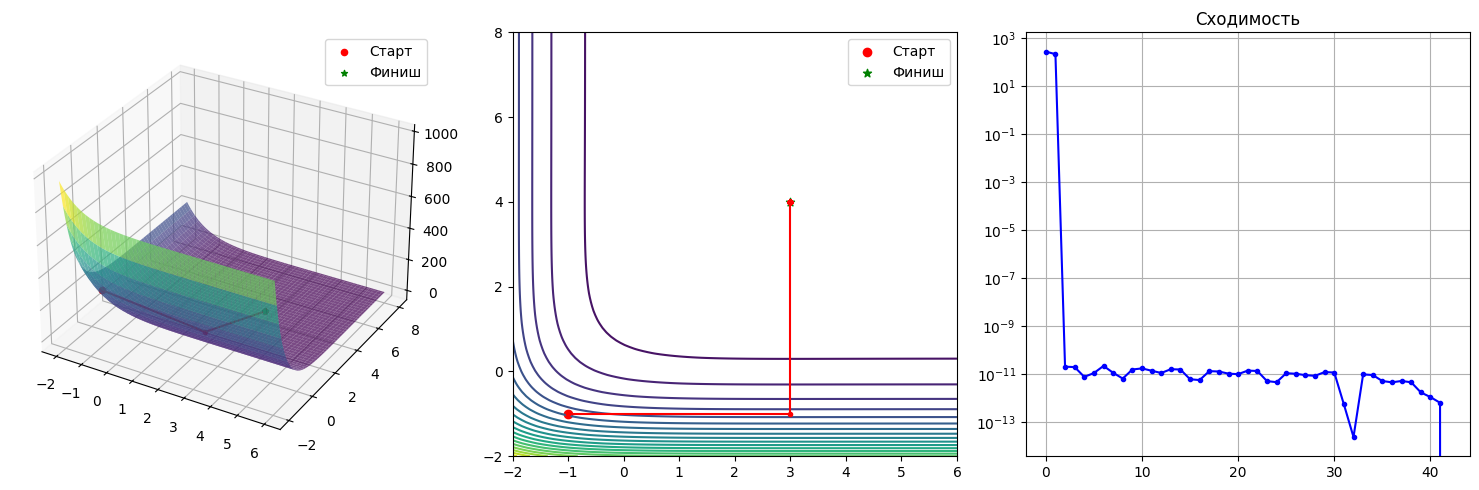

           x         y      f(x,y)
0  -1.000000 -1.000000  288.649211
1   2.999996 -1.000000  228.024721
2   2.999996  4.000000    9.264241
3   3.000004  4.000000    9.264241
4   3.000004  4.000008    9.264241
5   2.999999  4.000008    9.264241
6   2.999999  3.999998    9.264241
7   3.000007  3.999998    9.264241
8   3.000007  4.000006    9.264241
9   2.999997  4.000006    9.264241
10  2.999997  3.999995    9.264241
11  3.000005  3.999995    9.264241
12  3.000005  3.999994    9.264241
13  2.999999  3.999994    9.264241
14  2.999999  3.999994    9.264241
15  3.000007  3.999994    9.264241
16  3.000007  3.999994    9.264241
17  2.999997  3.999994    9.264241
18  2.999997  3.999993    9.264241
19  3.000005  3.999993    9.264241
20  3.000005  3.999993    9.264241
21  2.999999  3.999993    9.264241
22  2.999999  3.999993    9.264241
23  3.000007  3.999993    9.264241
24  3.000007  3.999993    9.264241
25  2.999996  3.999993    9.264241
26  2.999996  3.999993    9.264241
27  3.000004  3.9999

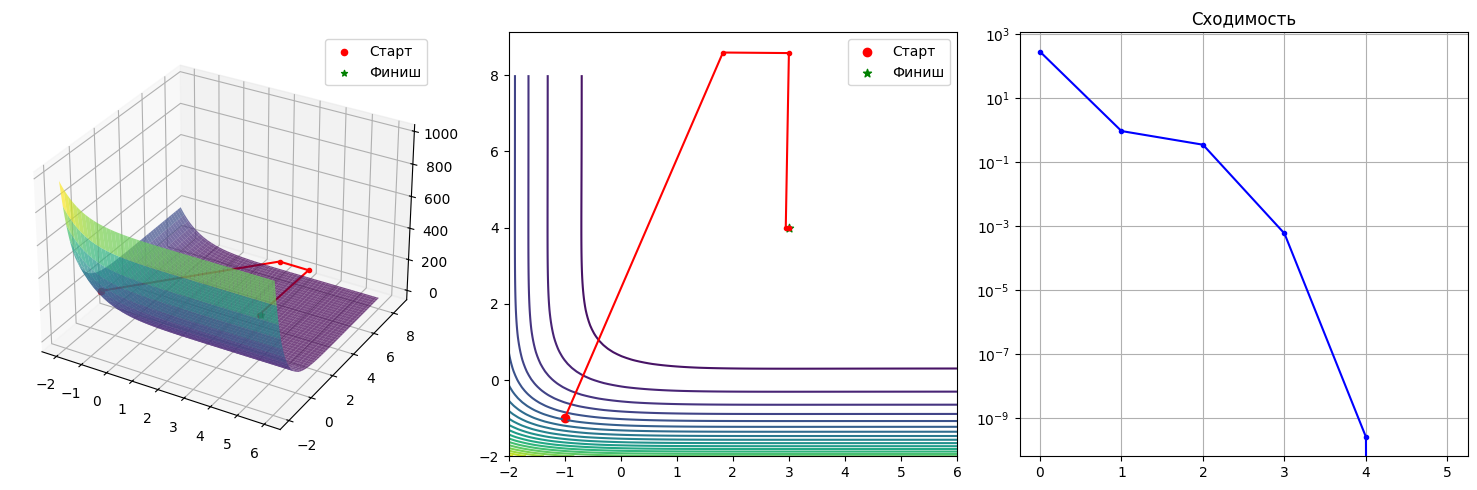

          x         y      f(x,y)
0 -1.000000 -1.000000  288.649211
1  1.823305  8.593172   10.190020
2  3.000576  8.578834    9.611050
3  2.944546  4.000689    9.264828
4  3.000000  4.000038    9.264241
5  3.000000  4.000000    9.264241 

Название метода: hooke_jeeves
Оптимальная точка: x* = [3.000000, 4.000000]
Значение функции: f(x*) = 9.264241
Количество итераций: 5


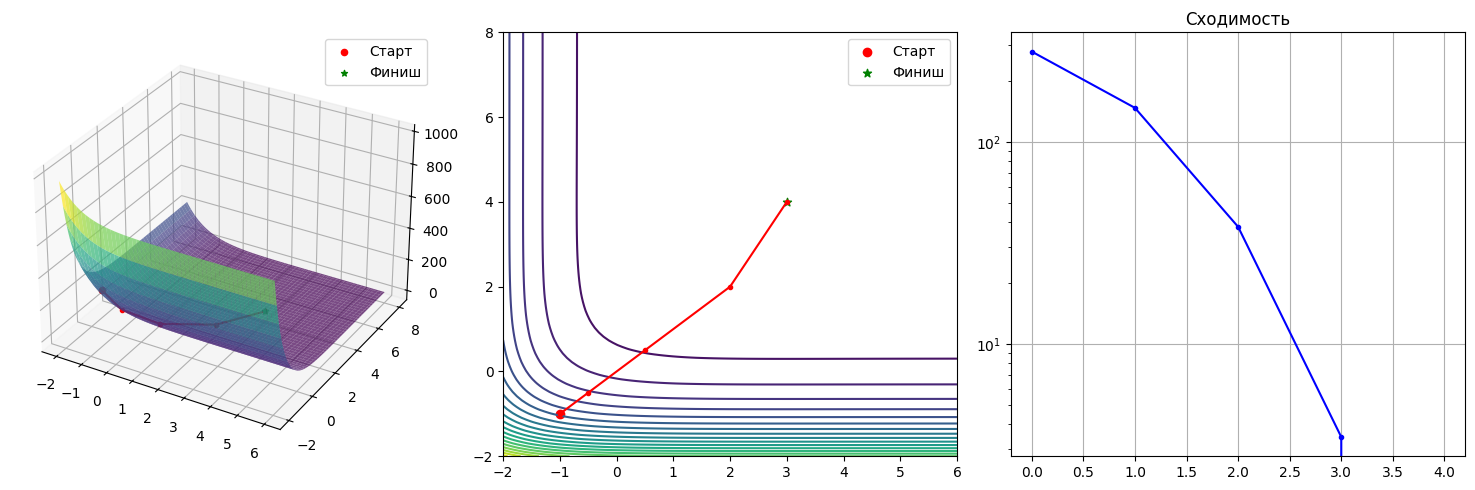

     x    y      f(x,y)
0 -1.0 -1.0  288.649211
1 -0.5 -0.5  156.360317
2  0.5  0.5   47.178769
3  2.0  2.0   12.718282
4  3.0  4.0    9.264241 

Название метода: rosenbrock
Оптимальная точка: x* = [3.000000, 4.000000]
Значение функции: f(x*) = 9.264241
Количество итераций: 61


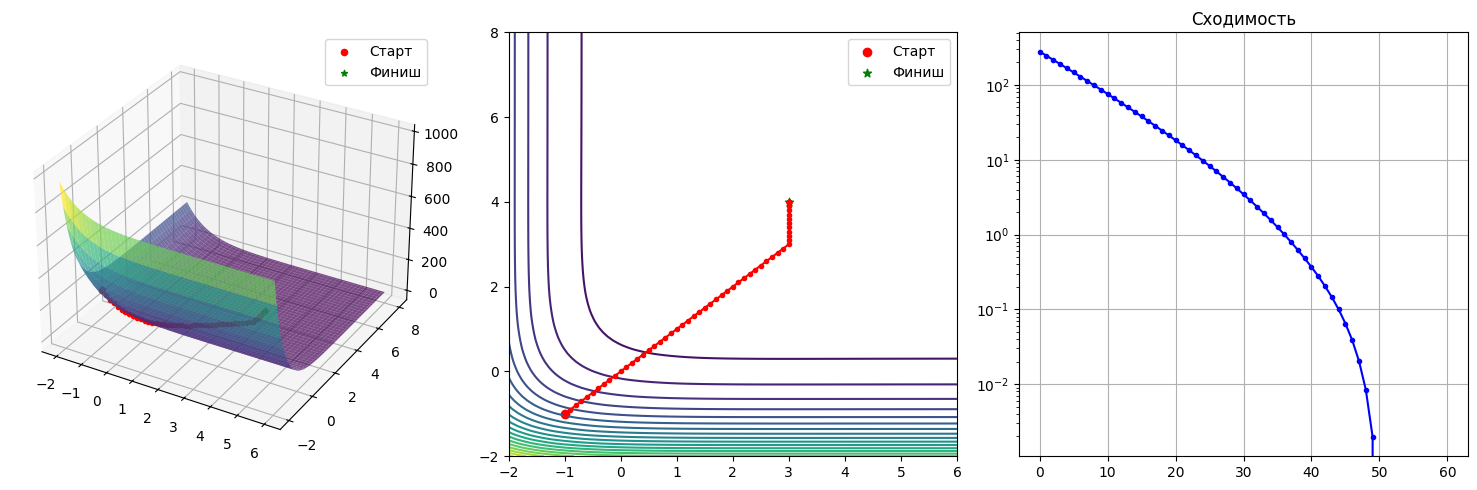

      x    y      f(x,y)
0  -1.0 -1.0  288.649211
1  -0.9 -0.9  255.374573
2  -0.8 -0.8  225.909512
3  -0.7 -0.7  199.830302
4  -0.6 -0.6  176.759363
..  ...  ...         ...
56  3.0  4.0    9.264241
57  3.0  4.0    9.264241
58  3.0  4.0    9.264241
59  3.0  4.0    9.264241
60  3.0  4.0    9.264241

[61 rows x 3 columns] 



In [193]:
methods = [gauss_seidel, steepest_descent, hooke_jeeves, rosenbrock]

for func in methods:
    eps = 1e-6
    x0 = [-1, -1]
    x_opt, history = func(f, x0, eps = eps)

    print(f"Название метода: {func.__name__}")
    print(f"Оптимальная точка: x* = [{x_opt[0]:.6f}, {x_opt[1]:.6f}]")
    print(f"Значение функции: f(x*) = {f(x_opt[0], x_opt[1]):.6f}")
    print(f"Количество итераций: {len(history)}")\

    visualize_optimization(f, history)

    results = []

    for point in history:
        results.append({
            "x": point[0],
            "y": point[1], 
            "f(x,y)": f(point[0], point[1])
        })

    results_df = pd.DataFrame(results)
    print(f"{results_df} \n")